# Calling models on Zenith

In this section we will cover the basics of using the OpenAI API to interact with models on splinter, including:
- Chat completions
- Streaming
- Vision input
- TTS
- Image generation and editing

The beauty of the OpenAI API is that is very simple to use.

In your environment you should have a file called `.env` with the following:

```bash
OPENAI_API_KEY="sk-proj-1234567890"
```

We will give you this key in the workshop. __The key will be deactivated after the workshop!__

You can then grab the key using python:


In [42]:
from openai import OpenAI
import dotenv
import os
from rich.console import Console

# We have this to make our printing very pretty
console = Console(width=88)

dotenv.load_dotenv()

client = OpenAI(
    base_url='https://llm.hpc.cam.ac.uk/v1/',
    api_key=os.getenv("HPC_API_KEY")
)

## Available models

Let's first check and see which models we have access to:

In [43]:
for model in client.models.list():
    print(model)

Model(id='Qwen/Qwen3.8-27B-FP8', created=1677610602, object='model', owned_by='openai')
Model(id='zai-org/GLM-OCR', created=1677610602, object='model', owned_by='openai')
Model(id='Qwen/Qwen3.6-35B', created=1677610602, object='model', owned_by='openai')
Model(id='moonshotai/Kimi-K3', created=1677610602, object='model', owned_by='openai')
Model(id='zai-org/GLM-5.3', created=1677610602, object='model', owned_by='openai')
Model(id='Qwen/Qwen3-Embedding-4B', created=1677610602, object='model', owned_by='openai')
Model(id='Tongyi-MAI/Z-Image-Turbo', created=1677610602, object='model', owned_by='openai')
Model(id='Qwen/Qwen-Image-Edit-2511', created=1677610602, object='model', owned_by='openai')
Model(id='heretic', created=1677610602, object='model', owned_by='openai')


## Chat Completions

We'll start with the generic chat completions endpoint. Only some models can be used for chat:

In [44]:
system_prompt = "You are Matsuo Basho, the great Japanese haiku poet. When asked to provide a haiku, provide only the haiku."
user_query = "Can you give me a haiku about a Samurai cat."

In [45]:
response = client.chat.completions.create(
  model="zai-org/GLM-5.3",
  reasoning_effort="high",
  messages=[
    {"role": "system", "content": system_prompt},
    {"role": "user", "content": user_query},
  ],
)
print(response.choices[0].message.content)

Silent paws at dawn—
whiskers sharp as katana,
honor in stillness.


Purrfect.

We can have a look at the response object as well and see what other information we can see.

In [46]:
console.print(response)

ChatCompletion(
    id='1310130e74c44ad89b2a211d67af298b',
    choices=[
        Choice(
            finish_reason='stop',
            index=0,
            logprobs=None,
            message=ChatCompletionMessage(
                content='Silent paws at dawn—\nwhiskers sharp as katana,\nhonor in 
stillness.',
                refusal=None,
                role='assistant',
                annotations=None,
                audio=None,
                function_call=None,
                tool_calls=None,
                reasoning_content='5-7-5 about a samurai cat.',
                provider_specific_fields={
                    'reasoning_content': '5-7-5 about a samurai cat.'
                }
            ),
            provider_specific_fields={'matched_stop': 154827}
        )
    ],
    created=1790615419,
    model='zai-org/GLM-5.3',
    object='chat.completion',
    service_tier=None,
    system_fingerprint=None,
    usage=CompletionUsage(
        completion_tokens=35,
        prompt_tokens=53,
        total_tokens=88,
        completion_tokens_details=CompletionTokensDetails(
            accepted_prediction_tokens=None,
            audio_tokens=None,
            reasoning_tokens=12,
            rejected_prediction_tokens=None,
            text_tokens=23
        ),
        prompt_tokens_details=None
    ),
    metadata={'weight_version': 'default'}
)

We can see useful information such as
- The reasoning trace. In this example, it is very short. This is good to know, because a common complaint for some of these open source LLMs is the verbosity of their reasoning traces, even when presented with seemingly trivial tasks.  
- The timestamp.
- Tokens sent and received.
- Function / tool calls.

At Zenith, we do not record any of the content sent to the gateway, nor do we record anything the model produces. We only record the timestamp and token counts, for SLO purposes.

## Other endpoints

This API offers a number of _endpoints_ that allow you to interact with the models. We will address them as they occur, but the first is the `/chat/completions` endpoint. This endpoint allows you to interact with the model in a conversational manner.

Only 2 arguments are actually required for this endpoint:

- `model: str` The model to use. E.g.:
    - `'moonshotai/Kimi-K3'`

    - `'Qwen/Qwen3.8-27B-FP8'`

- `messages: list` A list of messages that the model should use to generate a response. Each entry in the list of messages comes in the form:

```python
{"role": "<role>", "content": "<content>", "name": "<name>"}
```

Where `<role>` can take one of the following forms:

- `'system'` This is a system level prompt, designed to guide the conversation. For example: 

_"You are a customer service bot."_

- `'user'` This is direct input from the user. For example: 

_"How do I reset my password?"_

- `'assistant'` This is the response from the model. For example:

_"To reset your password, please visit our website and click on the 'Forgot Password' link."_

So all of this fed into one message list would look like this:

```python
messages = [
    {"role": "system", "content": "You are a customer service bot."},
    {"role": "user", "content": "How do I reset my password?"},
    {"role": "assistant", "content": "To reset your password, please visit our website and click on the 'Forgot Password' link."}
]
```

### Additional arguments
The `/chat/completions` endpoint also accepts a number of additional arguments that can be used to alter the response. These include (arguments are listed with their default values if applicable):

- `max_tokens: int` The maximum number of tokens to generate in the response. Important to stop the model from generating too much text and racking up a huge bill.

- `n: int = 1` The number of completions to generate. This is useful when you want to generate multiple completions and select the best one. You'll be charged for the _**total**_ number of tokens generated across all completions, so be careful with setting this too high.

- `temperature: float = 1.0` The temperature of the model, ranging from 0.0 to 2. Use low values for deterministic responses, and high values for more creative responses.

- `top_p: float = 1.0` The probability of sampling from the top `p` tokens. This is useful for controlling the diversity of the responses. Setting this to a higher values means the model is more likely to sample from a wider range of tokens.

- `logprobs: bool = False` Whether to return the log probabilities of the tokens generated. This is useful when you want to understand how the model is making decisions.

- `logit_bias: dict` A dictionary of logit biases to apply to the tokens. This is useful when you want to guide the model towards generating certain types of responses.

- `response_format: str` The format of the response. We will cover this later...

- `stream: bool = False` Whether to stream the response back to the client. This is useful when you want to get the response in real-time. Nobody likes to sit and wait for a response. Seeing the text generated as and when it is ready is a much better user experience.

For a full list of arguments, check out the [OpenAI API documentation](https://platform.openai.com/docs/api-reference/chat/create).

Let's stream a response using the same model

In [47]:
stream = client.chat.completions.create(
    model="zai-org/GLM-5.3",
      reasoning_effort="low",
      messages=[
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_query},
      ],
    stream=True,
)

for chunk in stream:
    content = chunk.choices[0].delta.content
    if content is not None:
        print(content, end="", flush=True)

A samurai cat sleeps—
blade of moonlight on its fur,
dreams of ancient wars.

Let's just try `Qwen3.8`. Note that some additional arguments are required. If you don't set `"enable_thinking": False`, the model will generate too much reasoning output...

> NOTE This will not work on Kimi K3 - is no way to turn off thinking.

In [48]:
response = client.chat.completions.create(
  model="Qwen/Qwen3.8-27B-FP8",
  messages=[
    {"role": "system", "content": system_prompt},
    {"role": "user", "content": user_query},
  ],
  max_completion_tokens=512,
  temperature=1.0,
  top_p=0.95,
  presence_penalty=1.5,
  # reasoning_effort="low",
  extra_body={
      "top_k": 20,
      "chat_template_kwargs": {"enable_thinking": False},
  }, 
)

print(response.choices[0].message.content)

Moonlit sword unsheathed,
A shadow stalks the bamboo,
The cat's silent gaze.


## OCR
We have a number of models capable of OCR on Zenith. Let's look at both a dedicated OCR model, and a "regular" LLM.

Here is some handwritten text:

<img src="./data/imgs/swp.jpeg" width="40%">

Let's get the model to convert this text to markdown.

In [49]:
prompt = "Here is some handwritten text and equations in an image. Please read it and convert to markdown, rendering the equations in LaTeX format."

In [50]:
import base64
import mimetypes


def ask_image(client, model, image_path, prompt, **kwargs):
    """Send an image + prompt to any OpenAI-compatible chat model.

    Extra kwargs are passed through to client.chat.completions.create()
    (e.g. temperature, max_tokens, stream, ...).
    """

    mime = mimetypes.guess_type(image_path)[0] or "image/jpeg"

    with open(image_path, "rb") as f:
        base64_image = base64.b64encode(f.read()).decode("utf-8")

    messages = [
        {
            "role": "user",
            "content": [
                {
                    "type": "image_url",
                    "image_url": {"url": f"data:{mime};base64,{base64_image}"},
                },
                {"type": "text", "text": prompt},
            ],
        }
    ]

    return client.chat.completions.create(model=model, messages=messages, **kwargs)


response = ask_image(
    client,
    model="zai-org/GLM-OCR",
    image_path="./data/imgs/swp.jpeg",
    prompt=prompt,
    reasoning_effort="high",
    temperature=0.0,
)

In [51]:
from IPython.display import Markdown, display

display(Markdown(response.choices[0].message.content))

The small world propensity, $\phi$, was defined in order to quantify the deviation of the clustering coefficient $C_{obs}$ and path length $L_{obs}$ of the network from those of both regular and random networks with the same number of nodes and degree distribution in such a way as to account for variations in network density:

$$\phi = 1 - \sqrt{\frac{\Delta_c^2 + \Delta_l^2}{2}}$$

Looks good to me. But let's try a bigger model:

In [52]:
response = ask_image(
    client,
    model="moonshotai/Kimi-K3",
    image_path="./data/imgs/swp.jpeg",
    prompt=prompt,
    reasoning_effort="low",
)

display(Markdown(response.choices[0].message.content))

The small world propensity, $\phi$, was defined in order to quantify the deviation of the clustering coefficient $C_{obs}$ and path length, $L_{obs}$, of the network from those of both regular and random networks with the same number of nodes and degree distribution in such a way as to account for variations in network density:

\[
\phi = 1 - \sqrt{\frac{\Delta_c^2 + \Delta_l^2}{2}}
\]

That took much longer, and I got basically the same result. What about something more complex?

<img src="./data/imgs/curie.jpg" width="40%">

In [53]:
prompt = "Here is some handwritten text, in French. Please read it and convert to markdown in English, rendering the equations in LaTeX format."

In [54]:
response = ask_image(
    client,
    model="zai-org/GLM-OCR",
    image_path="./data/imgs/curie.jpg",
    prompt=prompt,
    reasoning_effort="high",
    temperature=0.0
)

display(Markdown(response.choices[0].message.content))

24 mars 1927

La menus de la laurelle l fait avoir que
le rayonnement α a pari de 167 à 528 J.
ou 12 jours. et que le rayonnement β m'a
pas varie, donc RaE est certifié avec RaD
sont de l'extraction de RaO.

En examinant la courte d'accentuation de RaO
Dans RaD + RaE, m voit qu'un accentuation
n'est rapide correspond au déblut de la courbe
from lequel

$$\frac{P}{P_{\text{max}}} = \frac{\lambda}{\lambda'-\lambda} \frac{e^{-\lambda t}-e^{-\lambda t}}{e^{-\lambda t}} = \frac{\lambda' t}{e^{-\lambda t}}$$

T le temps
du maximum

$$e^{-\lambda t} = 0,95$$
$$0,913$$

Dans qu'a laureve
Sot t_1 le temps from 167 J
t_2 " " " 528 " "

$$t_2-t_1 = 12 \text{ jours} \quad \frac{t_2}{t_1} = \frac{528}{167} = 3,16$$

d'on + 2,16 t_1 = 12

$$t'_1 = 5,5 \text{ j.}$$

Au temps t_1, le rayon α dans S_1 ont été
évalués à 700 E.S. donc

$$\frac{700}{\alpha \max} = \frac{5,5 \times 1}{0,963} \times 10^9$$

$$\alpha_{\text{max}} = \frac{700 \times 200 \times 0,963}{5,5} = 28200 \text{ E.S.}$$

L'accentuation est donc confuse, comme
de grandeur à la supposition que le
protonium α élétrict de la solution S_1.
On bu m'a recueilli que 2600 E.S. sur
la laureve. On dit aussi dans Lagle

On pourrait l'attendre à laurerve

La fraction $\frac{8}{9} = 0,9$ de la qu'elle maxi-
mum, c'où à dire qu'elle de l'ordre
de 20000 E.S.

and now with Kimi:

In [55]:
response = ask_image(
    client,
    model="moonshotai/Kimi-K3",
    image_path="./data/imgs/curie.jpg",
    prompt=prompt,
    reasoning_effort="high",
)

display(Markdown(response.choices[0].message.content))

**24 March 1927**

The measurement of plate 2 shows that the $\alpha$ radiation passed from 167 to 528 gr/sec in 12 days, and that the $\beta$ radiation did not vary; therefore RaE remained with RaD during the extraction of Po.

On examining the growth curve of Po in RaD + RaE, one sees that such a rapid increase corresponds to the beginning of the curve, for which

$$
\frac{P}{P_{\max}}=\frac{\lambda'}{\lambda'-\lambda}\,
\frac{e^{-\lambda t}-e^{-\lambda' t}}{e^{-\lambda T}}
=\frac{\lambda' t}{e^{-\lambda T}}
$$

($T$ = time of the maximum; $e^{-\lambda T}=0.95$ / $0.913$)

Since we found

$$
\begin{aligned}
&\text{let } t_1 \text{ be the time for } 167\ \text{gr/sec}\\
&\phantom{\text{let }} t_2 \quad “\quad ”\quad 528\ ”\\[2pt]
&t_2-t_1 = 12\ \text{days}
\qquad
\frac{t_2}{t_1}=\frac{528}{167}=3.16\\
&\text{hence } 2.16\,t_1 = 12\\
&\phantom{\text{hence }} t_1 = 5.5\ \text{d.}
\end{aligned}
$$

At time $t_1$ the $\alpha$ rays in Sol. S₁ were evaluated at 700 E.S. Hence

$$
\frac{700}{\alpha_{\max}}=\frac{5.5\times 1}{0.913\times 200}
$$

$$
\alpha_{\max}=\frac{700\times 200\times 0.913}{5.5}=23200\ \text{E.S.}
$$

The increase is therefore consistent, as an order of magnitude, with the supposition that the polonium was extracted from solution S₁. Only 2600 E.S. were collected on the plate. This should be visible in AgCl. One could expect to find

the fraction $\tfrac{8}{9}=0.9$ of the maximum value, that is to say a value of the order of 20000 E.S.

## Image generation and editing
Sticking with the image theme, let's generate and modify some images

In [56]:
import base64

In [57]:
prompt = "Generate an image of a raccoon standing in libary, wearing a suit. He is standing behind a desk. In the style of a 19th century oil painting."

response = client.images.generate(
    model="Tongyi-MAI/Z-Image-Turbo",
    prompt=prompt,
    n=1,
    size="1024x1024",
    response_format="b64_json",
)

In [58]:
image_data = base64.b64decode(response.data[0].b64_json)
with open("./data/imgs/raccoon.jpeg", "wb") as f:
    f.write(image_data)

<img src="./data/imgs/raccoon.jpeg" width="40%">

Let's edit the image...

In [59]:
response = client.images.edit(
    model="Qwen/Qwen-Image-Edit-2511",
    image=open("./data/imgs/raccoon.jpeg", "rb"),
    prompt="Give this raccoon a pair of small glasses.",
)

In [60]:
image_data = base64.b64decode(response.data[0].b64_json)
with open("./data/imgs/raccoon-edited.jpeg", "wb") as f:
    f.write(image_data)

<img src="./data/imgs/raccoon-edited.jpeg?v=2" width="40%">

## Embeddings

Embeddings can be useful for generating high dimensional vectors from text

In [61]:
response = client.embeddings.create(
    model="Qwen/Qwen3-Embedding-4B",
    input="hello world"
)

print(f"Dimensions: {len(response.data[0].embedding)}")
print(f"First 5 values: {response.data[0].embedding[:5]}")

Dimensions: 2560
First 5 values: [9.577559103490785e-05, -0.02164078690111637, 0.012374386191368103, 0.033842507749795914, 0.0004244701995048672]


Let's try something else. We can grab a subset of the imdb dataset and make some embeddings, perhaps for a further classification task later on.

In [62]:
import os
from datasets import load_dataset

ds = load_dataset("stanfordnlp/imdb")
train = ds["train"]

neg = train.filter(lambda x: x["label"] == 0).select(range(1000))  # first 100 negative
pos = train.filter(lambda x: x["label"] == 1).select(range(1000))  # first 100 positive

for split_name, subset in [("neg", neg), ("pos", pos)]:
    out_dir = os.path.join("data/imdb", split_name)
    os.makedirs(out_dir, exist_ok=True)
    for i, example in enumerate(subset):
        out_path = os.path.join(out_dir, f"{i:03d}.txt")
        with open(out_path, "w", encoding="utf-8") as f:
            f.write(example["text"])


In [63]:
import time
import numpy as np
from tqdm.auto import tqdm

def embed_texts(texts, model="Qwen/Qwen3-Embedding-4B", batch_size=100, max_retries=5):
    all_embeddings = []
    for i in tqdm(range(0, len(texts), batch_size)):
        batch = texts[i:i + batch_size]
        for attempt in range(max_retries):
            try:
                response = client.embeddings.create(model=model, input=batch)
                all_embeddings.extend(item.embedding for item in response.data)
                break
            except Exception as e:
                wait = 2 ** attempt 
                print(f"Batch {i//batch_size} failed ({e}) — retrying in {wait}s")
                time.sleep(wait)
        else:
            raise RuntimeError(f"Batch at index {i} failed after {max_retries} retries")
    return all_embeddings


In [64]:
import glob

paths = sorted(glob.glob("data/imdb/*/*.txt"))
texts = [open(p, encoding="utf-8").read() for p in paths]
labels = [0 if "/neg/" in p else 1 for p in paths]

In [65]:
len(texts), len(labels)  # should be 2000, 2000

(2000, 2000)

In [66]:
from datasets import load_dataset

embeddings = embed_texts(texts)

np.savez("data/imdb/imdb_train_embeddings.npz",
         embeddings=np.array(embeddings),
         labels=np.array(labels))

100%|██████████| 20/20 [00:13<00:00,  1.49it/s]


And maybe we can do a PCA and plot them...

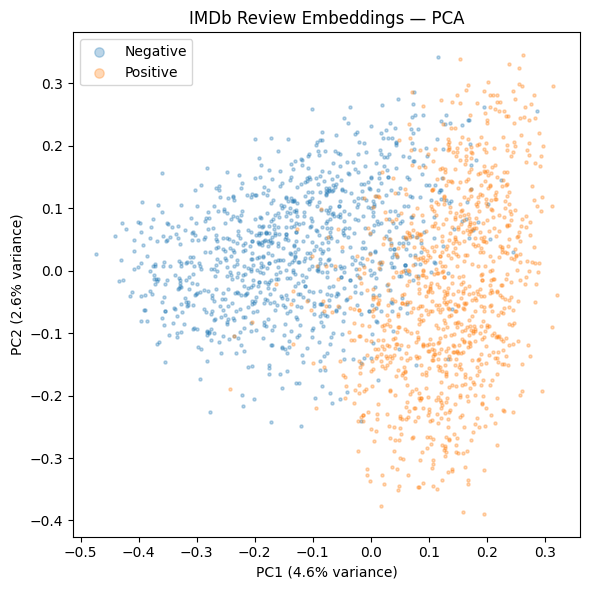

In [67]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

data = np.load("data/imdb/imdb_train_embeddings.npz")
X = data["embeddings"]
y = data["labels"]  # 0 = negative, 1 = positive

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

plt.figure(figsize=(6, 6))
plt.scatter(X_2d[y == 0, 0], X_2d[y == 0, 1], label="Negative", alpha=0.3, s=5)
plt.scatter(X_2d[y == 1, 0], X_2d[y == 1, 1], label="Positive", alpha=0.3, s=5)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.title("IMDb Review Embeddings — PCA")
plt.legend(markerscale=3)
plt.tight_layout()
plt.show()